In [ ]:
# HOMEWORK04 Bike-sharing 自行车共享系统 EDA+可视化

In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw04.ipynb")

In [2]:
# Run this cell to set up your notebook. Make sure ds100_utils.py is in this assignment's folder
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from pathlib import Path
import ds100_utils

# Default plot configurations
%matplotlib inline
plt.rcParams['figure.figsize'] = (16,8)
plt.rcParams['figure.dpi'] = 150
sns.set()

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display, Latex, Markdown

## 加载数据：华盛顿特区的自行车共享系统
变量定义：
Variable       | Description
-------------- | ------------------------------------------------------------------
instant | record index
dteday | date
season | 1. spring <br> 2. summer <br> 3. fall <br> 4. winter
yr | year (0: 2011, 1:2012)
mnth | month ( 1 to 12)
hr | hour (0 to 23)
holiday | whether the day is a holiday or not
weekday | day of the week
workingday | if the day is neither a weekend nor a holiday
weathersit | 1. clear or partly cloudy <br> 2. mist and clouds <br> 3. light snow or rain <br> 4. heavy rain or snow
temp | normalized temperature in Celsius (divided by 41)
atemp | normalized "feels-like" temperature in Celsius (divided by 50)
hum | normalized percent humidity (divided by 100)
windspeed| normalized wind speed (divided by 67)
casual | count of casual users
registered | count of registered users
cnt | count of total rental bikes, including casual and registered  

从GitHub下载数据

In [3]:
# Run this cell to download the data; no further action is needed.

# data_url = 'https://github.com/DS-100/fa20/raw/gh-pages/resources/assets/datasets/hw3-bikeshare.zip'
# data_url = 'https://gh-proxy.com/https://github.com/DS-100/fa20/raw/gh-pages/resources/assets/datasets/hw3-bikeshare.zip'
# file_name = 'data.zip'
# data_dir = 'data/'

# dest_path = ds100_utils.fetch_and_cache(data_url=data_url, data_dir=data_dir, file=file_name)
# print('Saved at {}'.format(dest_path))

dest_path = 'data/data.zip'

zipped_data = zipfile.ZipFile(dest_path, 'r')

data_dir = Path('data')
zipped_data.extractall(data_dir)


print("Extracted Files:")
for f in data_dir.glob("*"):
    print("\t",f)

Extracted Files:
	 data/bikeshare.txt
	 data/data.zip


In [4]:
# Run this cell to look at the top of the file; no further action is needed.
for line in ds100_utils.head(data_dir/'bikeshare.txt'):
    print(line,end="")

instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0,3,13,16
2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.8,0,8,32,40
3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.8,0,5,27,32
4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0,3,10,13


In [5]:
# Run this cell to view some metadata; no further action is needed.
print("Size:", (data_dir/"bikeshare.txt").stat().st_size, "bytes")
print("Line Count:", ds100_utils.line_count(data_dir/"bikeshare.txt"), "lines")

Size: 1156736 bytes
Line Count: 17380 lines


加载数据到DataFrame中

In [6]:
# Run this cell to load the data; no further action is needed.
bike = pd.read_csv(data_dir/'bikeshare.txt')
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Q1a 数据的粒度是多少（即每行代表什么）？
A: 一行表示一个小时hr内，对应的天气、温度、湿度、风速和随机用户和注册用户及其总数

### Q1b 使用这些数据来研究华盛顿特区的自行车使用情况。根据数据中存在的粒度和变量，使用这些数据可能有哪些限制？可以收集哪些其他数据类别/变量来解决其中一些限制？
A:缺乏用户信息和自行车骑行路线/目的信息(from gemin)

## 数据准备
将`holiday`, `weekday`, `workingday`, 和 `weathersit`从整数变量转换为指定类别的字符串
1. `holiday`: 转换为 `yes` 和 `no`。*提示：* 假期较少。  
1. `weekday`: 将 `'weekday'` 列改为使用 3 个字母的标签（`'Sun'`、`'Mon'`、`'Tue'`、`'Wed'`、`'Thu'`、`'Fri'` 和 `'Sat'`），而不用当前的数值。假设 `0` 对应 `Sun`，`1` 对应 `Mon`，依此类推，按前一句的顺序。  
1. `workingday`: 转换为 `yes` 和 `no`。  
1. `weathersit`: 应将每个值替换为 `Clear`、`Mist`、`Light` 或 `Heavy`。假设 `1` 对应 `Clear`，`2` 对应 `Mist`，依此类推，按前一句的顺序。

In [7]:
# bike.dtypes

In [8]:
holiday_dict = {0: 'no', 1:'yes'}
bike['holiday'] = bike['holiday'].map(holiday_dict)
bike.head(1)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,no,6,0,1,0.24,0.2879,0.81,0.0,3,13,16


In [9]:
bike['weekday'] = bike['weekday'].replace({0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'})
bike['workingday'] = bike['workingday'].replace({0:'no', 1:'yes'})
bike['weathersit'] = bike['weathersit'].replace({1:'Clear', 2:'Mist', 3:'Light', 4:'Heavy'})
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1


In [10]:
grader.check("q2a")

q2a results: All test cases passed!

### Q2b(Wednesdays)
bike中有多少条记录对应星期三，赋值给`num_wednesdays`

In [11]:
num_wednesdays = len(bike[bike['weekday'] == 'Wed'])
num_wednesdays

2475

In [12]:
grader.check("q2b")

q2b results: All test cases passed!

### Q2c 计算每日总计数
构造`daily_counts`，由`dteday`索引包含`casual`、`registered`、`workingday`三列


In [13]:
daily_counts = bike.groupby("dteday").agg({"casual": sum, "registered": sum, "workingday": "first"})
daily_counts.head()

,casual,registered,workingday
dteday,,,
2011-01-01,331,654,no
2011-01-02,131,670,no
2011-01-03,120,1229,yes
2011-01-04,108,1454,yes
2011-01-05,82,1518,yes


In [14]:
grader.check("q2c")

q2c results: All test cases passed!

## Q3 探索骑车人员的分布
首先比较休闲骑手和注册骑手的每日计数分布。<br>
**可视化有用方法的表格：Matplotlib和Seaborn常用函数表**
| 函数                                            | 描述                                                                                                                                |
| --------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| `plt.title(name)`                             | 为当前图形添加标题 `name`。                                                                                                                 |
| `plt.xlabel(name)`                            | 为 x 轴添加标签 `name`。                                                                                                                 |
| `plt.ylabel(name)`                            | 为 y 轴添加标签 `name`。                                                                                                                 |
| `plt.plot(x, y)`                              | 绘制 `x` 与 `y` 的折线图。                                                                                                                |
| `plt.scatter(x, y)`                           | 绘制 `x` 与 `y` 的散点图。                                                                                                                |
| `plt.hist(x, bins=None)`                      | 绘制 `x` 的直方图；`bins` 可以是整数或序列。                                                                                                      |
| `plt.bar(x, height)`                          | 绘制类别 `x` 及其对应高度 `height` 的条形图。                                                                                                    |
| `sns.histplot(data=, x=, y=, hue=, kde=)`     | 绘制分布图；`data` 为 `DataFrame`；`x`、`y` 为 `data` 中的列名，指定在 x 轴和 y 轴上的位置；`hue` 为 `data` 中的列名，根据 `hue` 为图形添加子类别；`kde` 为布尔值，决定是否叠加 KDE 曲线。 |
| `sns.lineplot(data=, x=, y=, hue=)`           | 绘制折线图。                                                                                                                            |
| `sns.scatterplot(data=, x=, y=, hue=, size=)` | 绘制散点图；`size` 为向量，根据 `hue` 为每个子类别指定点的大小。                                                                                           |
| `sns.kdeplot(data=, x=, y=)`                  | 绘制核密度估计图；`data` 为 `DataFrame`；`x`、`y` 为 `data` 中的列名，指定在 x 轴和 y 轴上的位置。                                                             |
| `sns.jointplot(data=, x=, y=, kind=)`         | 绘制两个变量的联合图，中间为 KDE 图，侧边为每个变量的分布图；`kind` 决定分布图的可视化类型，可为 `scatter`、`kde` 或 `hist`。                                                  |


### Q3a 使用sns.histplot创建一个图，该图覆盖了自行车用户的每日计数分布，使用蓝色表示休闲骑手，绿色表示注册骑手。记录的时间粒度应该是每日计数。使用`daily_counts`

In [15]:
daily_counts.head()

,casual,registered,workingday
dteday,,,
2011-01-01,331,654,no
2011-01-02,131,670,no
2011-01-03,120,1229,yes
2011-01-04,108,1454,yes
2011-01-05,82,1518,yes


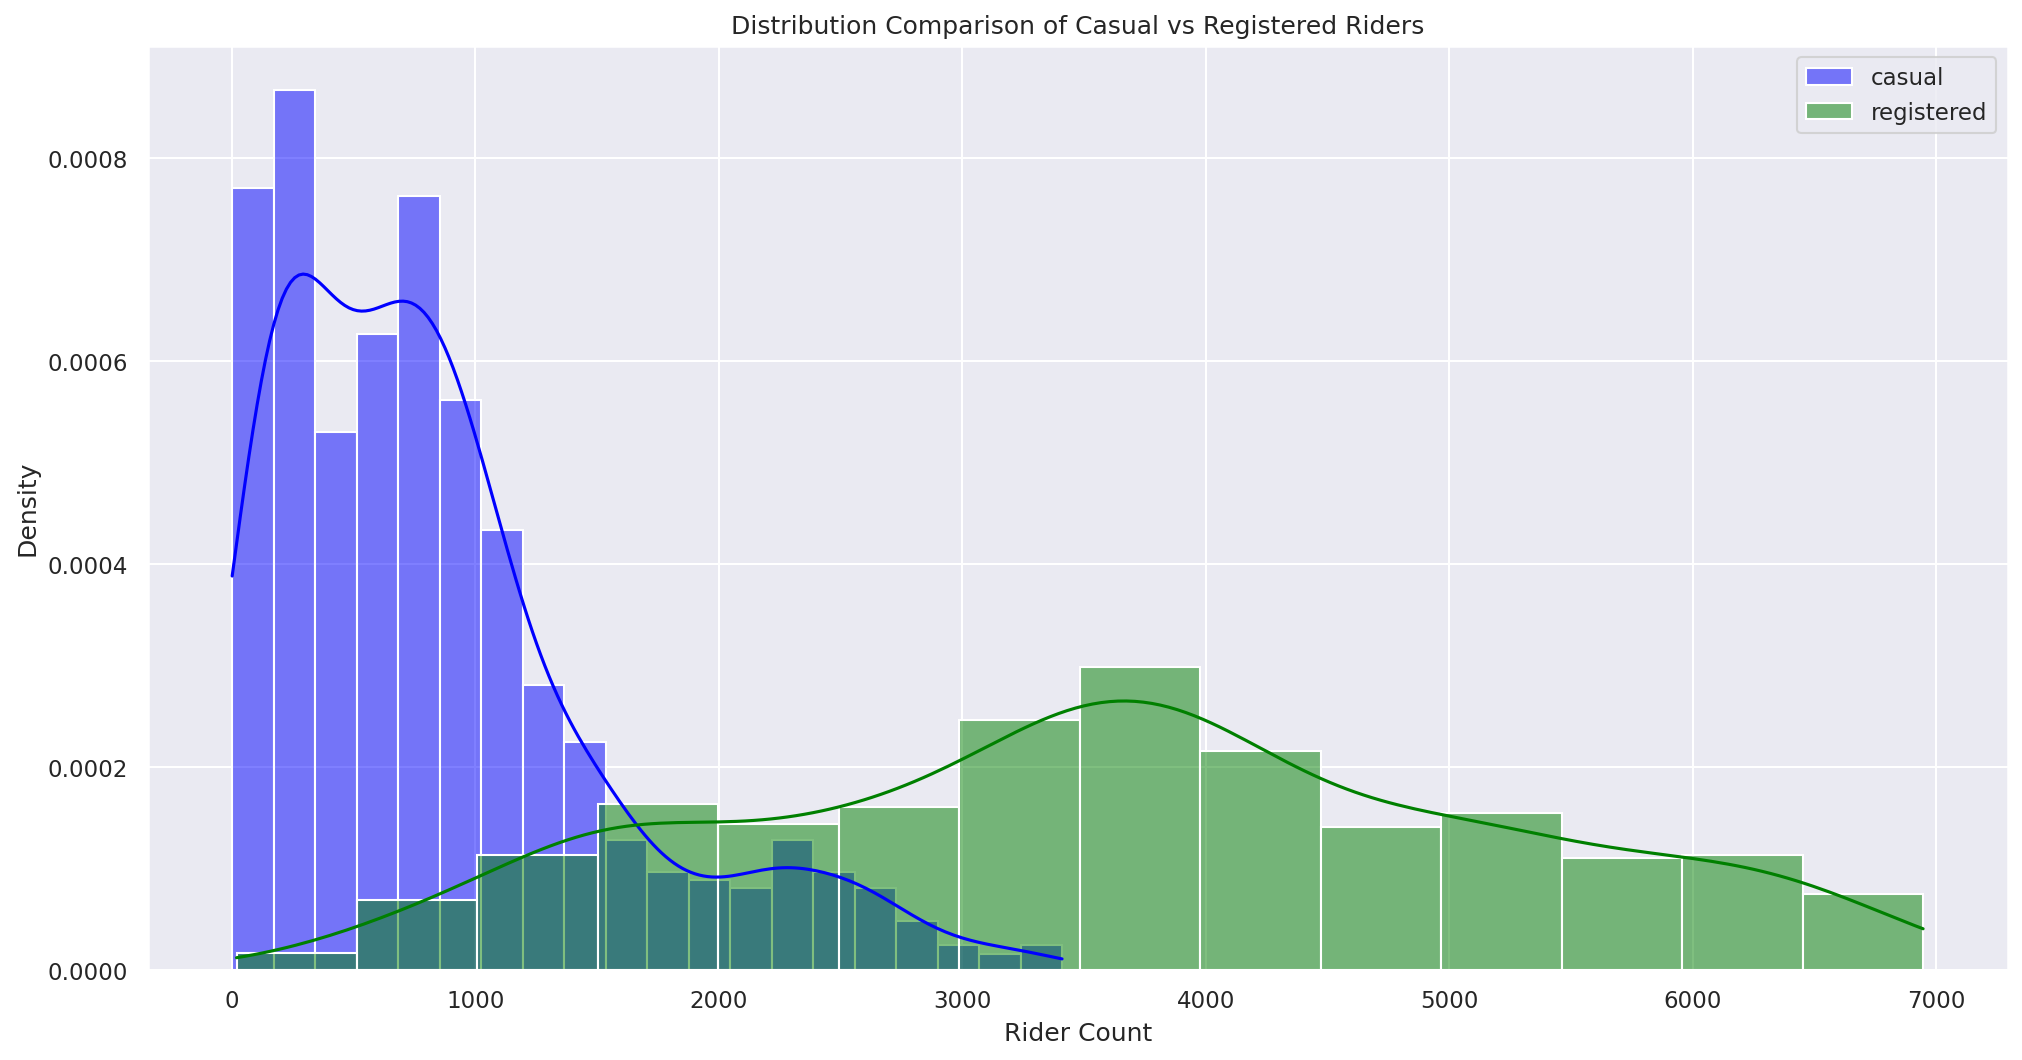

In [22]:
sns.histplot(data=daily_counts, x='casual', kde=True, stat='density', color='blue', label='casual')
sns.histplot(data=daily_counts, x='registered', kde=True, stat='density', color='green', label='registered')
plt.title('Distribution Comparison of Casual vs Registered Riders')
plt.xlabel('Rider Count')
plt.ylabel('Density')
plt.legend()
plt.show()

### Q3c 使用`sns.lmplot`绘制散点图研究`casual`计数和`registered`计数之间的关系
使用`bike`DataFrame绘制每小时计数

scatter_kws：传递字典，"s"控制点的大小

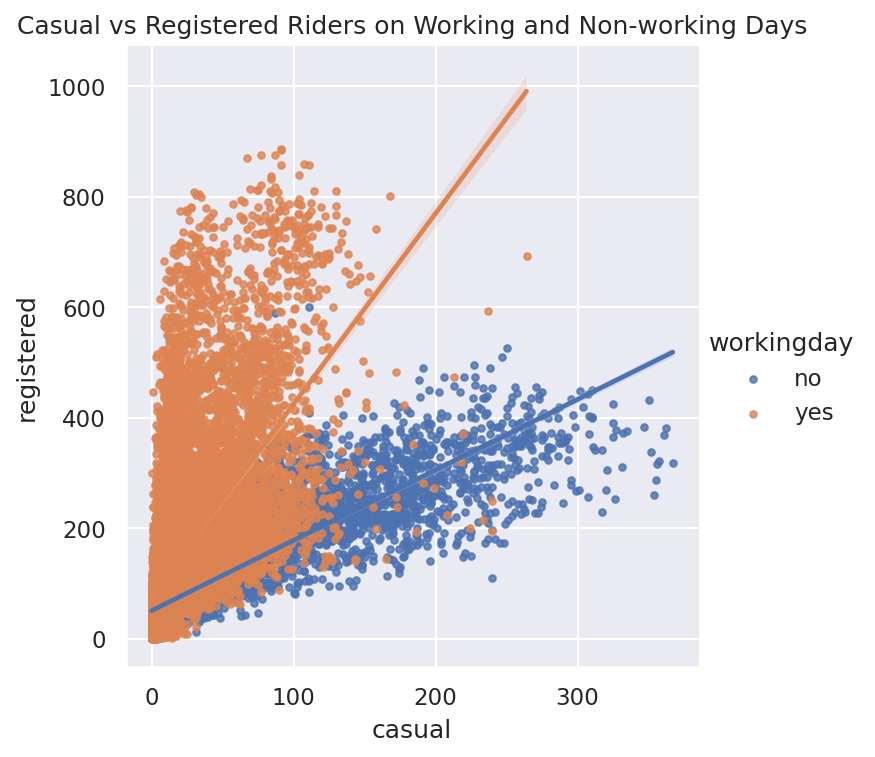

In [26]:
sns.set(font_scale=1)
sns.lmplot(data=bike,x='casual', y='registered', hue='workingday', scatter_kws={"s": 10})
plt.title('Casual vs Registered Riders on Working and Non-working Days')
plt.xlabel('casual')
plt.ylabel('registered')
# plt.legend()
plt.show()

# Q4 可视化
**overplotting**：当数据点过多、过于密集时，它们在图上相互重叠、相互遮挡，以至于无法看清数据真实分布情况<br>
使用`sns.kdeplot`来可视化

In [31]:
sns.kdeplot(data=daily_counts, x='casual', y='registered')
plt.title('KDE Plot Comparison of Registered vs Casual Riders');

### Q4a 双变量核密度图
使用`daily_counts`<br>
调用`sns.kdeplot`，查看`hue`参数

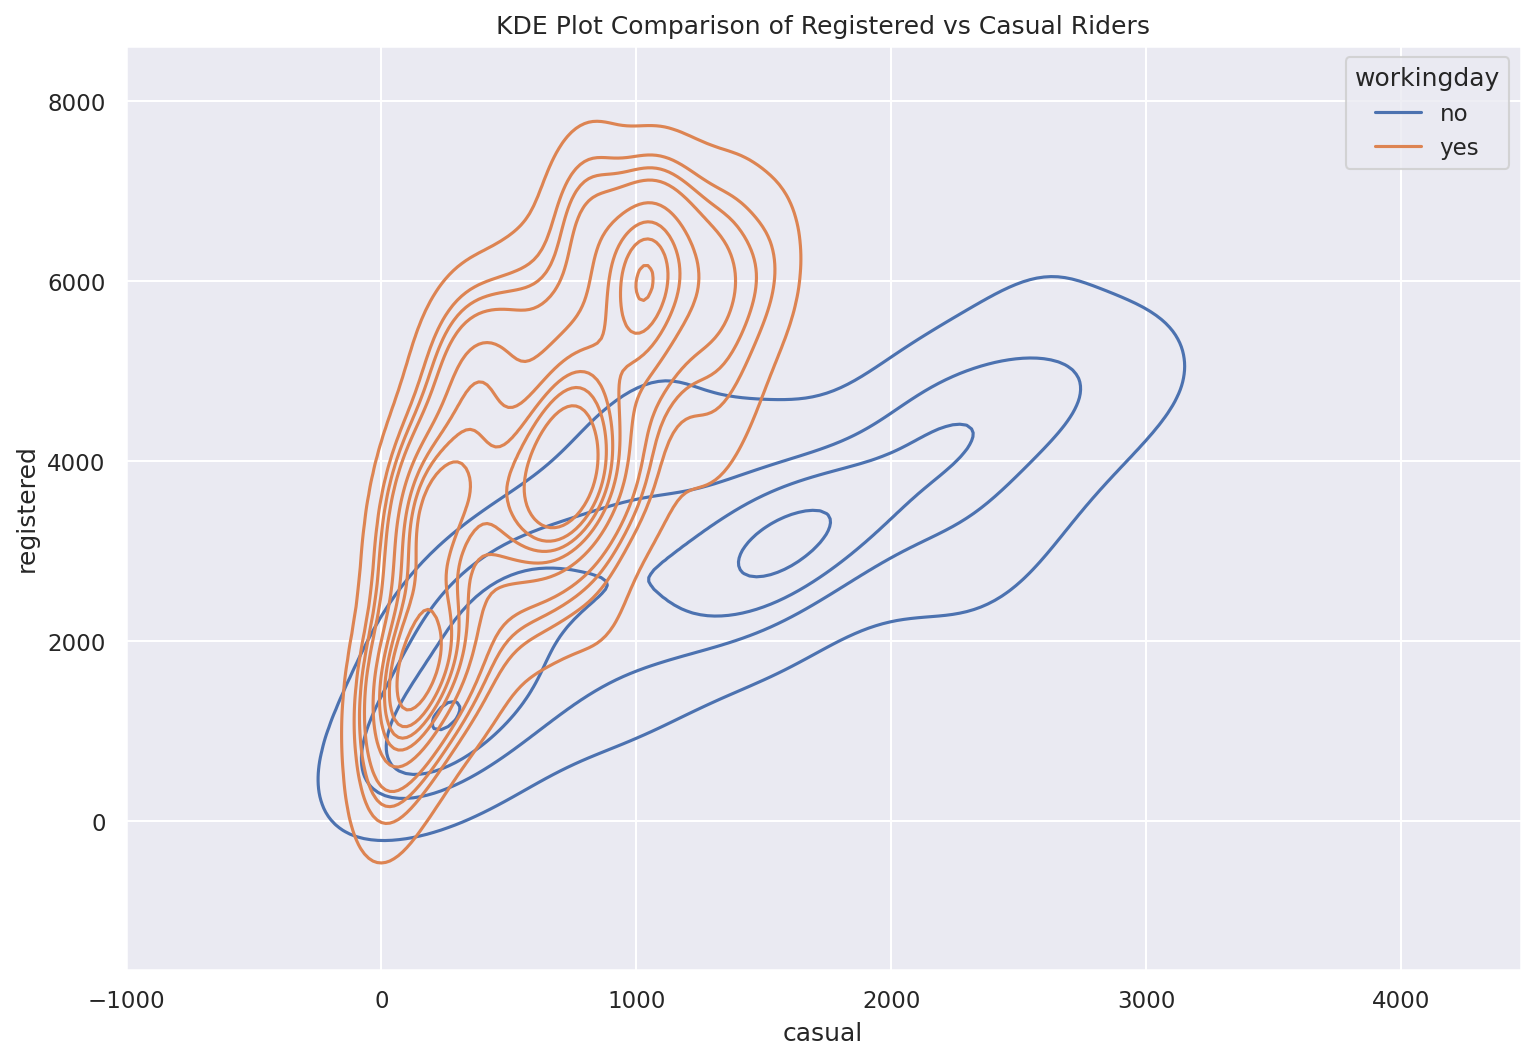

In [37]:
# Set the figure size for the plot
plt.figure(figsize=(12,8))
sns.kdeplot(data=daily_counts, x='casual', y='registered', hue='workingday',fill=False)
plt.xlabel('casual')
plt.ylabel('registered')
plt.title('KDE Plot Comparison of Registered vs Casual Riders')
# plt.legend()
plt.show()

## 5 连接图
构建以下一组三个图，其中主图显示了一起绘制的注册骑手和临时骑手的每日计数的核密度估计值的轮廓，<br>
两个“边距”图（在图的顶部和右侧）提供了每个变量的单变量核密度估计值。<br>
请注意，此图使在两种不同条件（工作日与周末）下更难看到休闲和注册之间的线性关系。你应该利用 daily_counts<br>
**sns.jointplot及其kind参数**

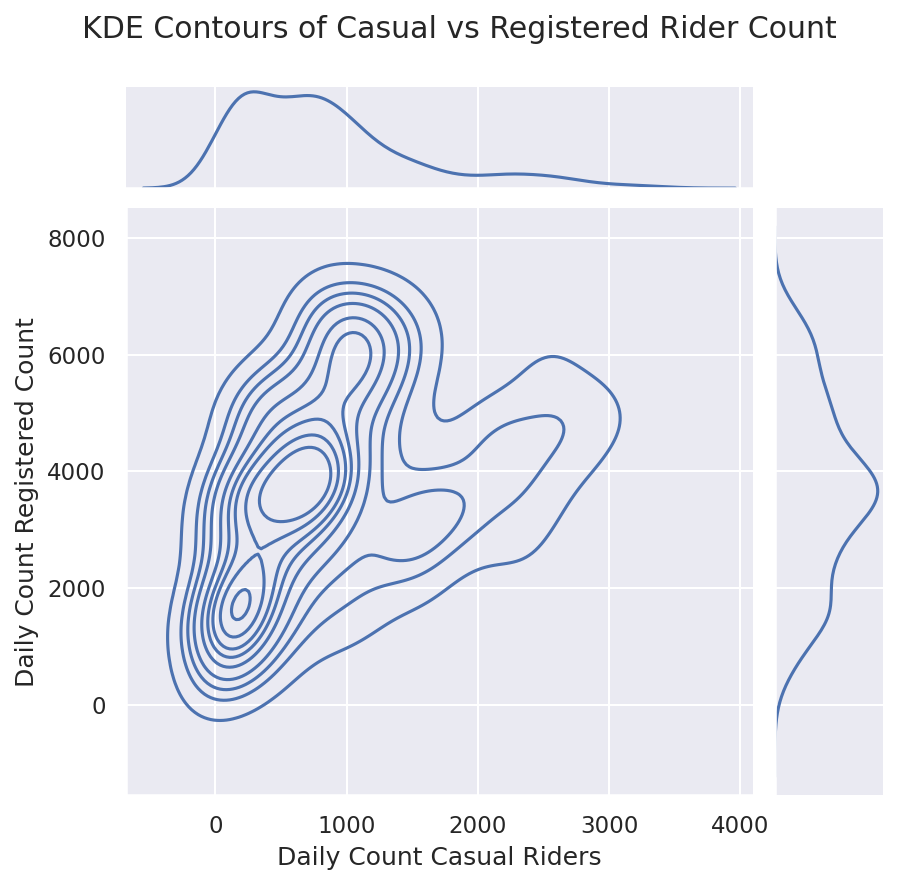

In [43]:
graph = sns.jointplot(data=daily_counts, x='casual', y='registered', kind='kde')
graph.set_axis_labels("Daily Count Casual Riders", "Daily Count Registered Count")
plt.suptitle("KDE Contours of Casual vs Registered Rider Count")
plt.subplots_adjust(top=0.9);
plt.show()

## Q6 了解Daily模式
### Q6a 绘制`bike`上一天中每个小时的平均Riders数量，按Riders类型分层

In [44]:
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1


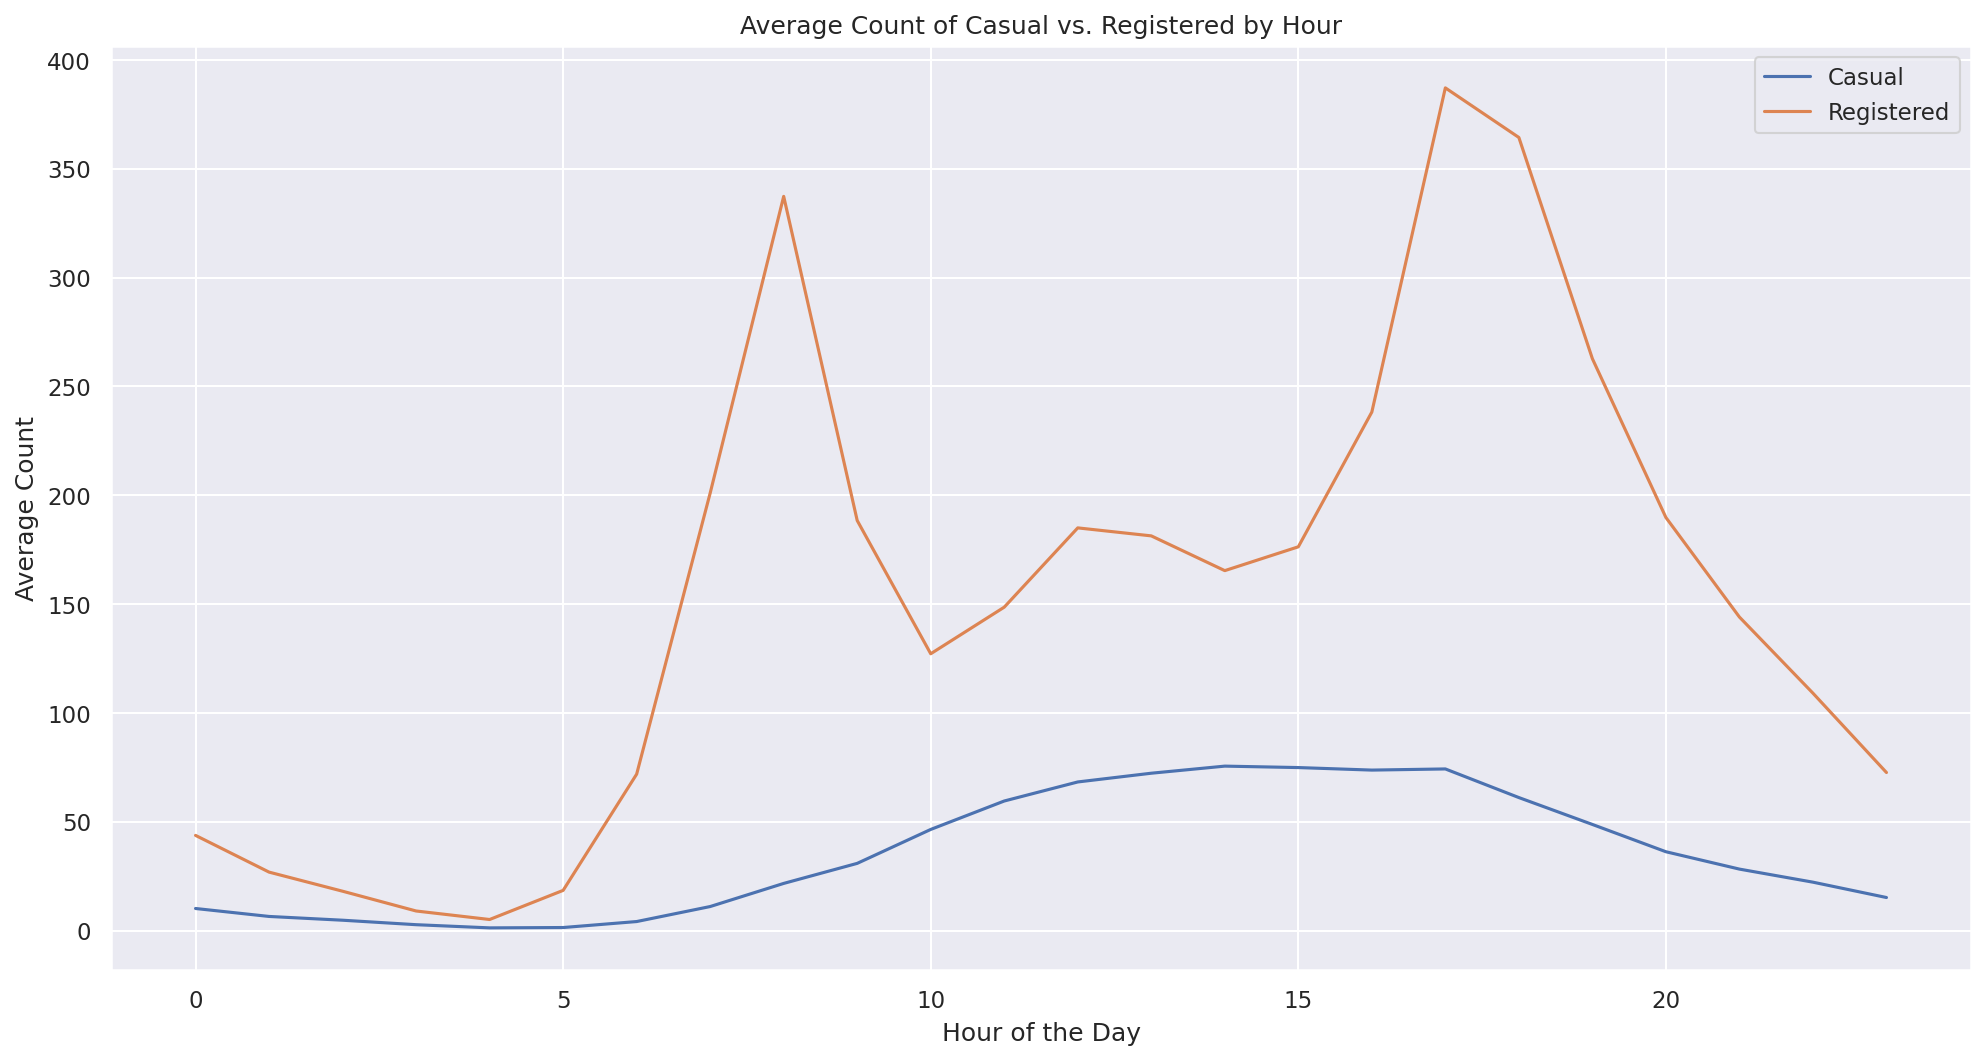

In [49]:
hourly_counts = bike.groupby('hr')[['casual', 'registered']].agg('mean')
plt.plot(hourly_counts.index, hourly_counts['casual'], label='Casual')
plt.plot(hourly_counts.index, hourly_counts['registered'], label='Registered')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Count')
plt.legend()
plt.title('Average Count of Casual vs. Registered by Hour')
plt.show()

### Q6b 从上图中的观察
A：注册骑手的数量比casual骑手明显要多，但峰值主要集中于上下班高峰期，说明注册骑手可能大部分是上班族<br>
casual骑手起伏相较来说比较小，主要是下午比较多，可能是下午出去办事/出去玩的人

## Q7 探索Ride-Sharing和天气的关系
### Q7a 在`bike`中创建新列`prop_casual`计算每条记录中casual骑手占所有骑手的比例

In [50]:
bike['prop_casual'] = bike['casual'] / (bike['cnt'])
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,prop_casual
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16,0.187500
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40,0.200000
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32,0.156250
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13,0.230769
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1,0.000000


In [51]:
grader.check("q7a")

q7a results: All test cases passed!

为了检查casual骑手比例与温度之间的关系，我们可以使用 sns.scatterplot 创建一个散点图。<br>
我们甚至可以使用颜色/色调来编码有关星期几的信息。运行下面的单元格，你会看到我们最终会得到一个无法解释的大混乱。

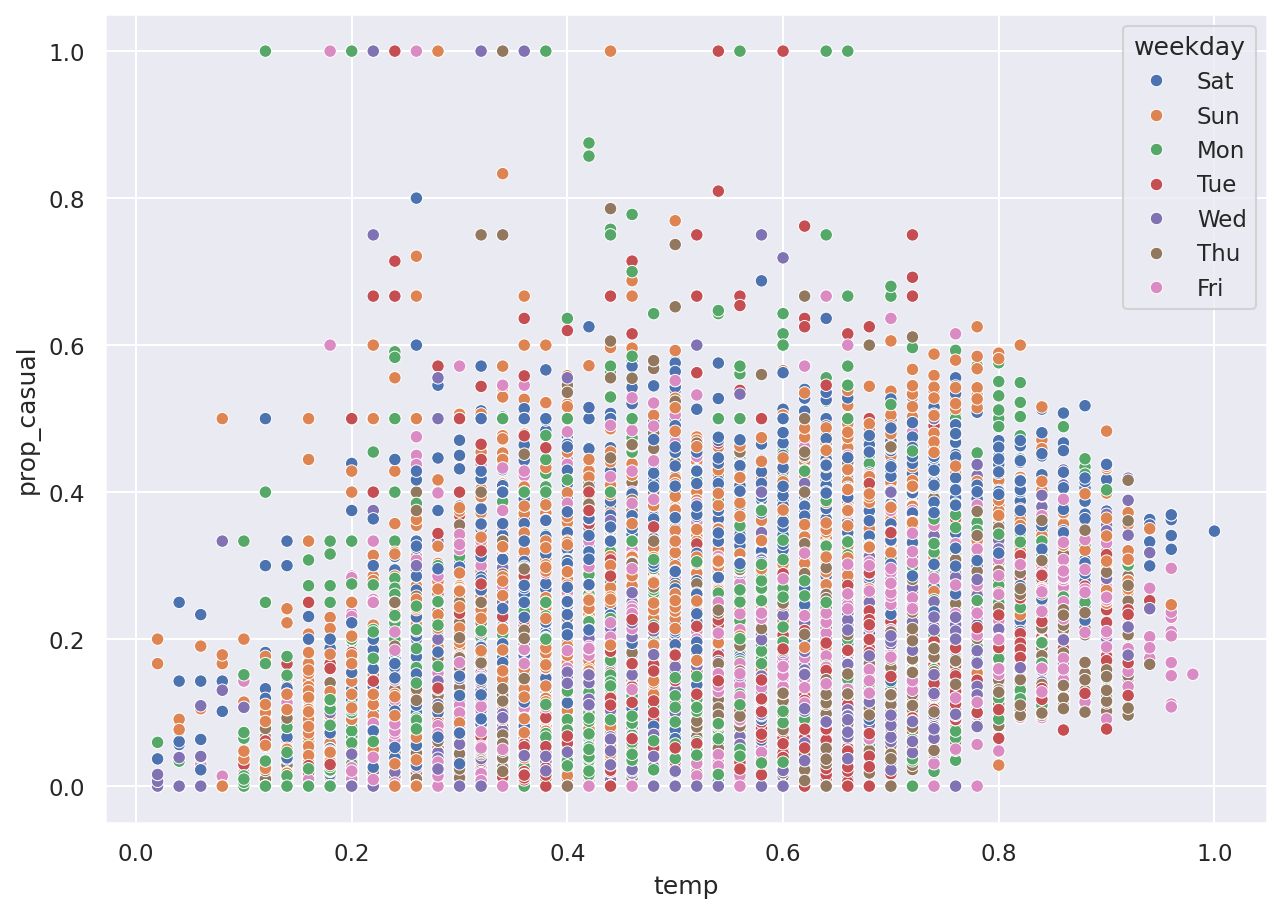

In [54]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=bike, x='temp', y='prop_casual', hue='weekday');
plt.show()

我们可以尝试使用如下所示的 sns.lmplot 进行线性回归，这暗示了温度和比例随意之间的一些关系，但该图仍然相当没有说服力。

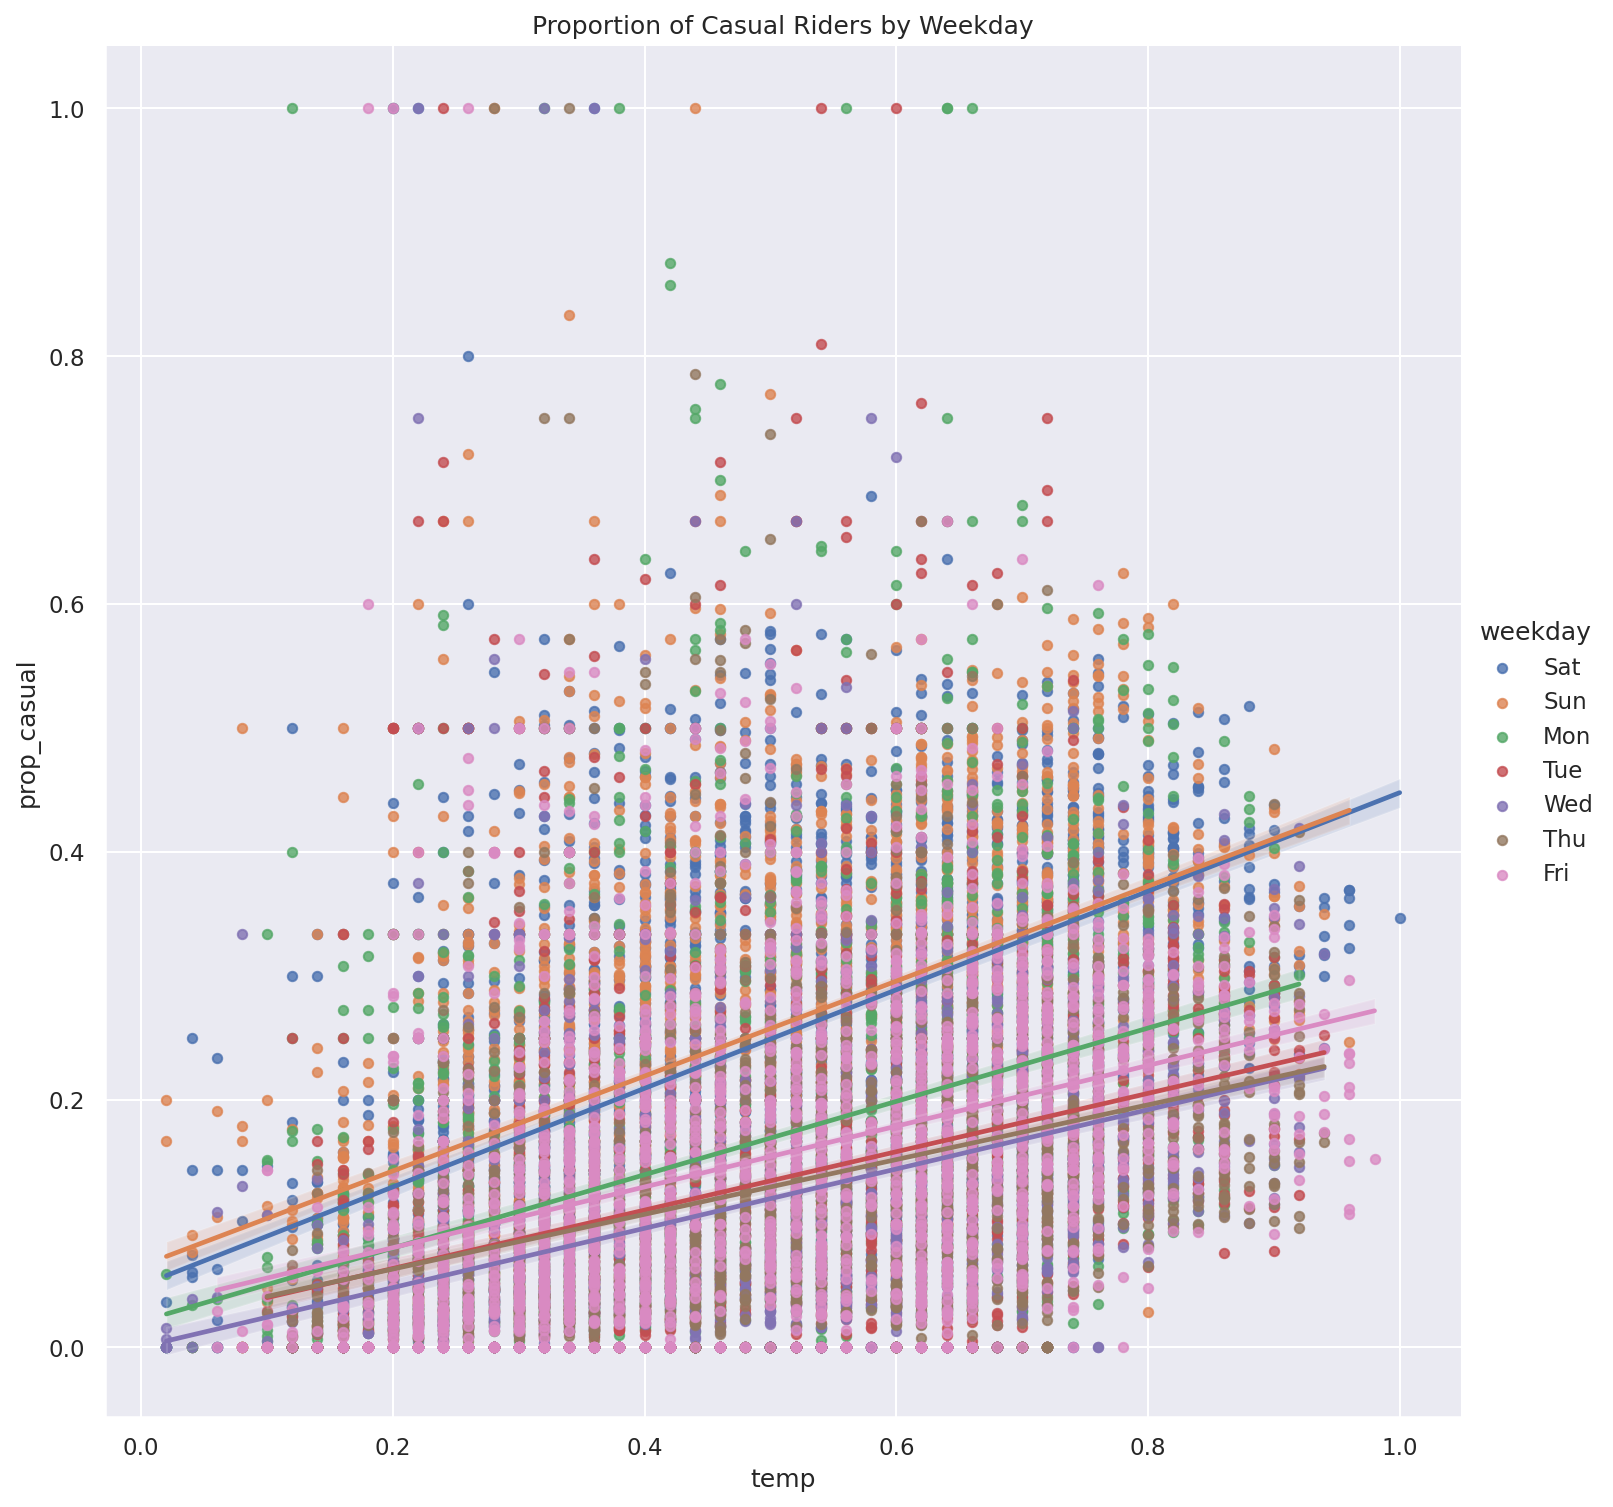

In [57]:
sns.lmplot(data=bike, x='temp', y='prop_casual', hue='weekday', scatter_kws={"s": 20}, height=10)
plt.title("Proportion of Casual Riders by Weekday");
plt.show()

更好的方法是使用局部平滑。<br>
基本思想是，对于每个 x 值，我们计算某种具有代表性的 y 值，以捕获接近该 x 值的数据。<br>
局部平滑的一种技术是“局部加权散点图平滑”或 LOWESS。我们在下面展示了一个示例。显示的红色曲线是散点图的平滑版本。

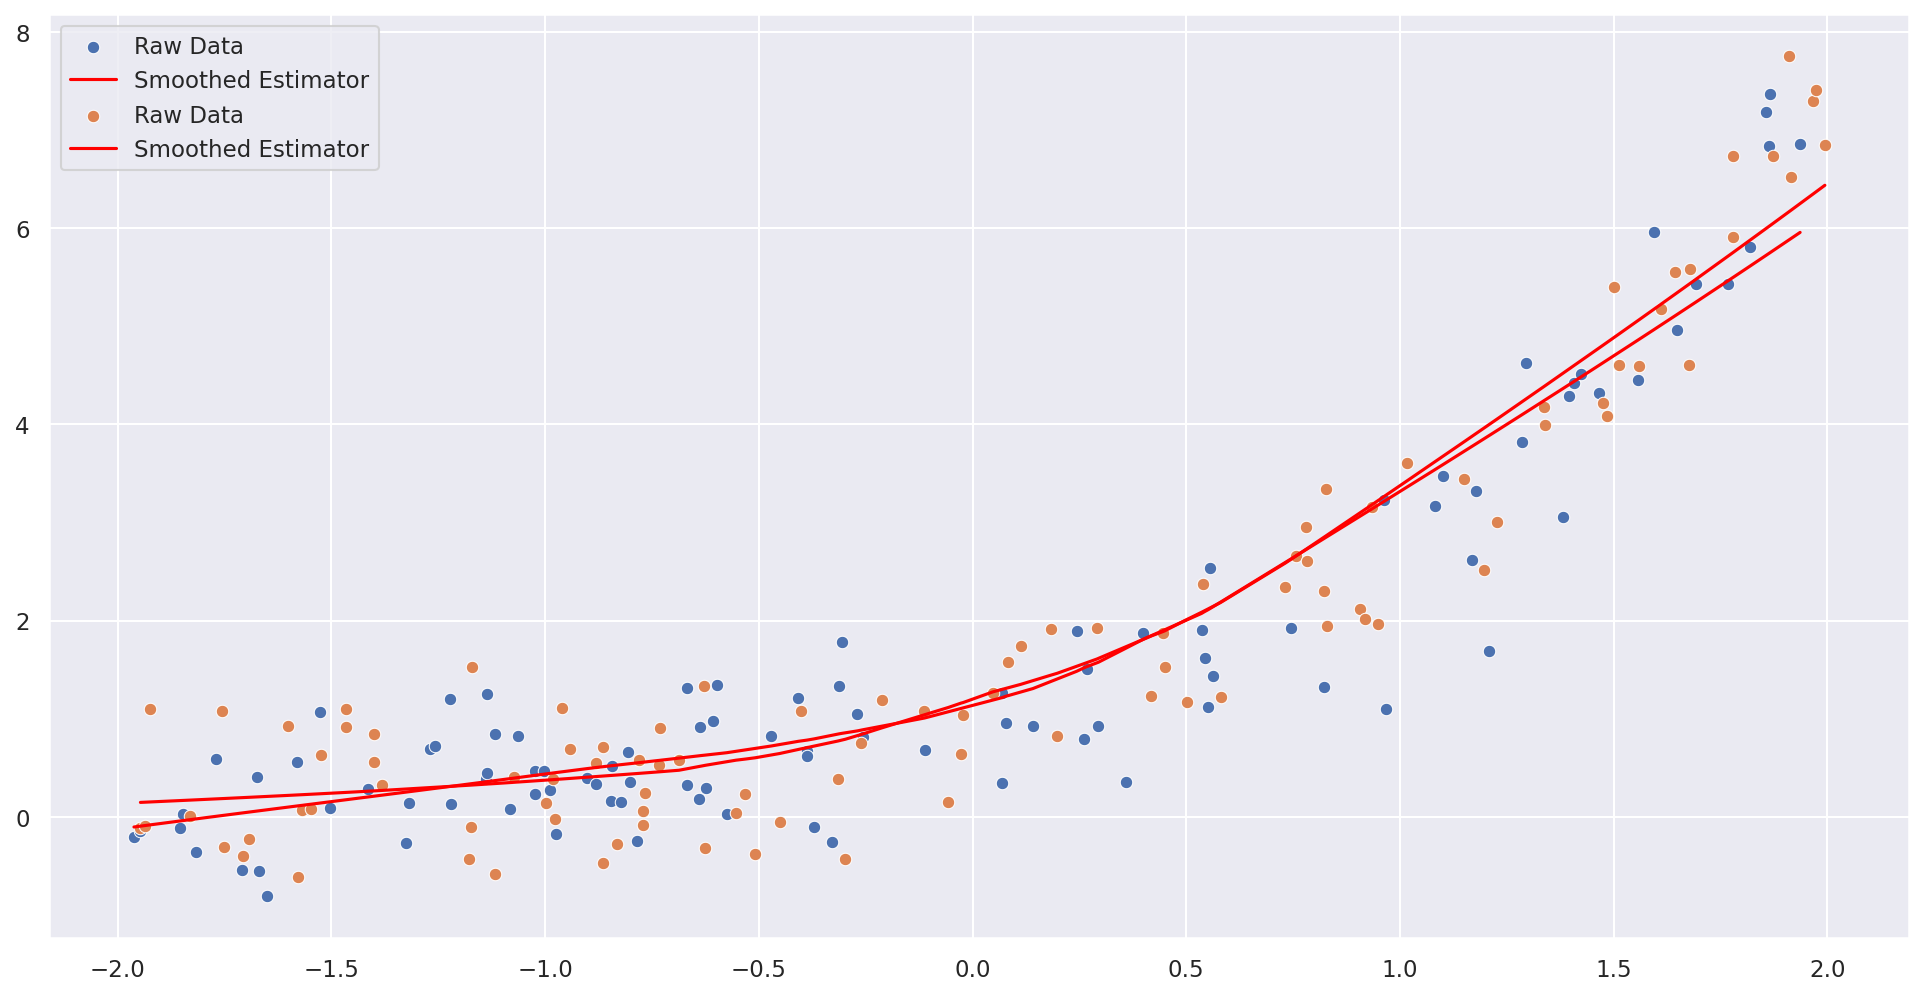

In [60]:
from statsmodels.nonparametric.smoothers_lowess import lowess
# Make noisy data
x_obs = np.sort(np.random.rand(100)*4.0 - 2)
y_obs = np.exp(x_obs) + np.random.randn(100) / 2.0

# Plot a regular scatterplot with our noisy data 
sns.scatterplot(x=x_obs, y=y_obs, label="Raw Data")

# Pass in the noisy data to lowess to generate the smoothed y-values, 
# we want to preserve the relative ordering of the y-values, which is why return_sorted=False
y_smooth = lowess(y_obs, x_obs, return_sorted=False)

# Plot a red line using the smoothed y-values
sns.lineplot(x=x_obs, y=y_smooth, label="Smoothed Estimator", color='red')
plt.legend();
plt.show()

### Q7b 使用`bike`数据绘制7条线分别代表一周中的每天，x轴是温度，y轴是casual骑手比例的平滑版本

你应该像上面的示例那样使用 [`statsmodels.nonparametric.smoothers_lowess.lowess`](http://www.statsmodels.org/dev/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html  )。但与上面的示例不同，**仅绘制 LOWESS 曲线**，不要绘制实际数据，否则会导致过度重叠。对于这个问题，最简单的方法是使用循环。

你无需与示例图中的颜色完全一致，只要你的图中颜色能够清楚地区分每一天即可。

**提示：**
* 先只绘制一周中的一天，确保你能成功完成这一步。然后再考虑使用 `for` 循环对一周中的所有天重复此绘图操作。

* `lowess` 函数期望先传入 `y` 坐标，再传入 `x` 坐标。你还应将 `return_sorted` 参数设置为 `False`。

* **你需要将本数据集中存储的归一化温度重新缩放到华氏度。** 请查看本 notebook 中标题为“Loading Bike Sharing Data”的部分，了解（归一化的）温度字段的描述，以知道如何先转换回摄氏度。随后，将其转换为华氏度。默认情况下，温度字段的范围是 0.0 到 1.0。如有需要，$\text{华氏度} = \text{摄氏度} \times \frac{9}{5} + 32$。

注意：如果你更喜欢用摄氏度绘图，也可以！只需记得相应地转换，以确保图形仍然可读。

In [61]:
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,prop_casual
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16,0.187500
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40,0.200000
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32,0.156250
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13,0.230769
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1,0.000000


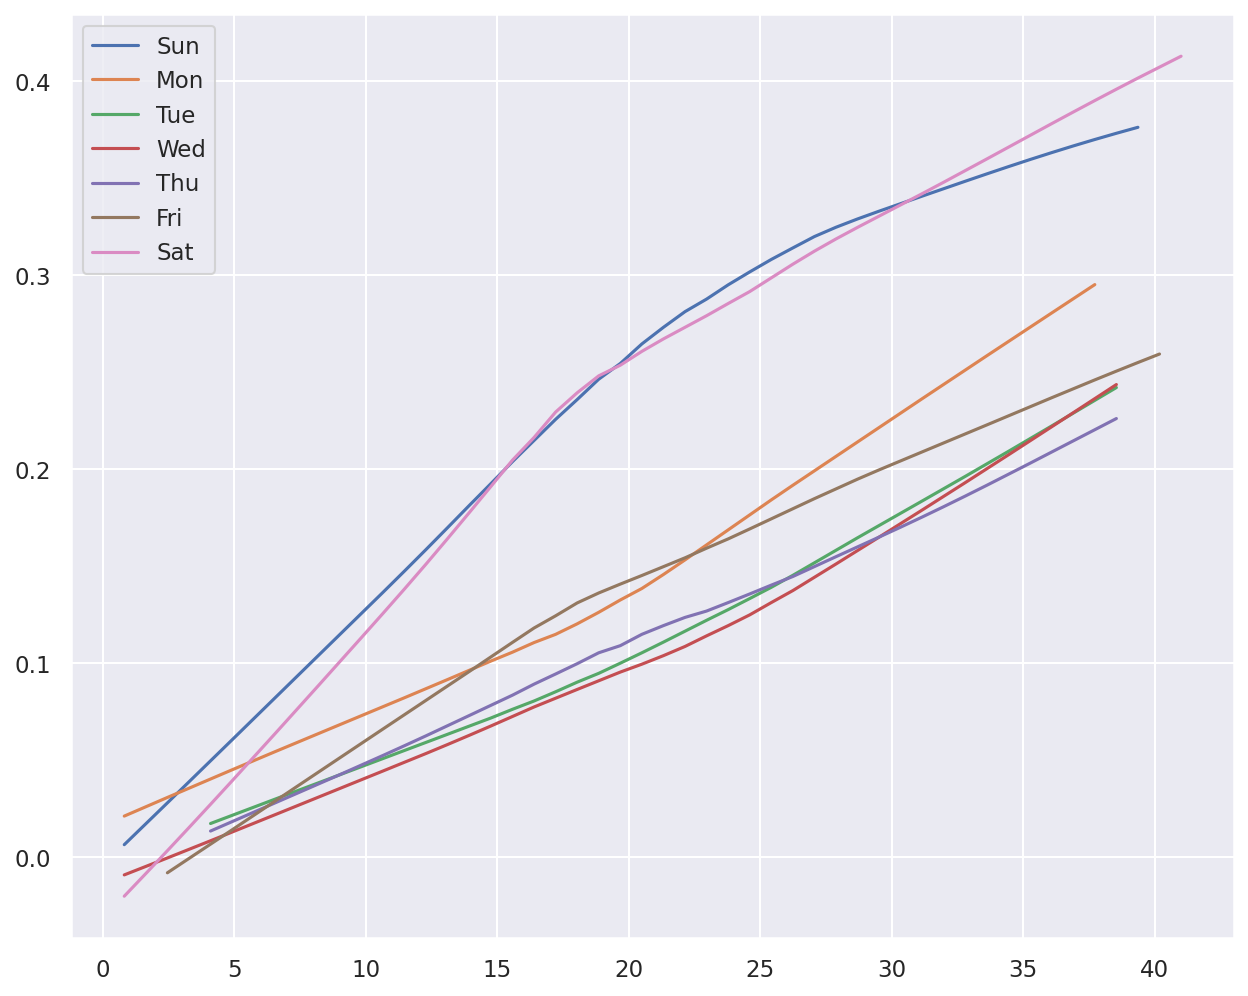

In [69]:
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.figure(figsize=(10,8))
# x_obs = bike['temp'] * 41
# y _obs = bike['prop_casual']

# y_smooth = lowess(y_obs, x_obs, return_sorted=False)

weekdays = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

for weekday in weekdays:
    day = bike[bike['weekday'] == weekday][['temp', 'prop_casual']]
    day = day.sort_values(by='temp')
    x_obs = day['temp']* 41
    y_obs = day['prop_casual']
    y_smooth = lowess(y_obs, x_obs, return_sorted=False)
    plt.plot(x_obs, y_smooth, label=weekday)
plt.legend()
plt.show()

### Q7c`prop_casual`如何随温度变化？
`prop_casual`随温度升高而增加；周末和周中的变化趋势略有不同